# RAND/US DAILY EXCHANGE RATE

## PROBLEM STATEMENT
In financial exchange rate there is a sense of unpredictability due to economical factors and other factors that mag affect exchange rate,this makes people either traders,citizens or foreigners due random guess on when to go do the money exchange.

### Main Objective
To find patterns and behavior of exchange rates over time,is it seasons,trends that creates this patterns through statistics to give us a conclusive conclusion and which model will be suitable to predict the exchange rates better

### sub objectives
1.To learn on the exchange rates patterns using historical data so as to give guided decisions

2.To find a model that will generalize and give accurate results and predict 7 days in advance to help in planning


In [41]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor

import numpy as np

In [2]:
df=pd.read_csv("rand.csv")
df

,Date,Rand / Dollar Daily
0,5/1/2023,18.29
1,5/2/2023,18.37
2,5/3/2023,18.46
3,5/4/2023,18.22
4,5/5/2023,18.27
...,...,...
271,5/15/2024,18.37
272,5/16/2024,18.29
273,5/17/2024,18.19
274,5/20/2024,18.13


In [3]:
df.shape

(276, 2)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 276 entries, 0 to 275
Data columns (total 2 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Date                 276 non-null    object 
 1   Rand / Dollar Daily  276 non-null    float64
dtypes: float64(1), object(1)
memory usage: 4.4+ KB


### Data Cleaning

In [5]:
df['Date']=pd.to_datetime(df['Date'])#helps in changing date from object to date time

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 276 entries, 0 to 275
Data columns (total 2 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Date                 276 non-null    datetime64[ns]
 1   Rand / Dollar Daily  276 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 4.4 KB


In [7]:
df.isna().sum()

Date                   0
Rand / Dollar Daily    0
dtype: int64

In [8]:
df.duplicated().sum()

0

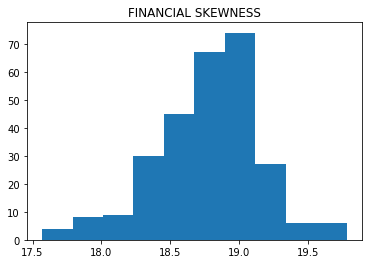

In [9]:
#check for skewness
plt.hist(df['Rand / Dollar Daily'])
plt.title("FINANCIAL SKEWNESS")
plt.show()

In [10]:
df['Rand / Dollar Daily'].skew()

-0.38036270245977444

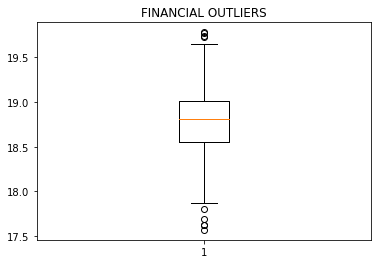

In [11]:
plt.boxplot(df['Rand / Dollar Daily'])
plt.title("FINANCIAL OUTLIERS")
plt.show()

In [12]:
Q1 = df['Rand / Dollar Daily'].quantile(0.25)
Q3 = df['Rand / Dollar Daily'].quantile(0.75)


In [13]:
IQR = Q3 - Q1


In [14]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR


In [15]:
df['Rand_Dollar_Winsor'] = df['Rand / Dollar Daily']

df.loc[df['Rand_Dollar_Winsor'] < lower_bound, 'Rand_Dollar_Winsor'] = lower_bound
df.loc[df['Rand_Dollar_Winsor'] > upper_bound, 'Rand_Dollar_Winsor'] = upper_bound

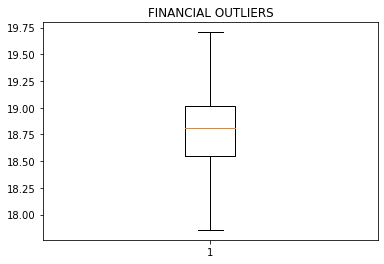

In [16]:
plt.boxplot(df['Rand_Dollar_Winsor'])
plt.title("FINANCIAL OUTLIERS")
plt.show()

### FEATURE ENGINEERING/EDA

investigating which is the appropriate way to do feature engineering and also see relationships between the columns 

In [17]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.month_name()

In [18]:
monthly_pattern = df.groupby('Month')['Rand / Dollar Daily'].mean()

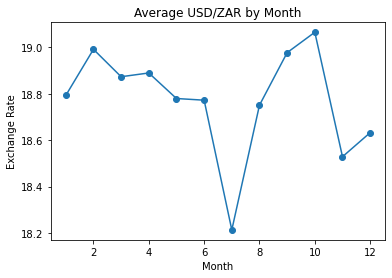

In [19]:
monthly_pattern.plot(marker='o')
plt.title("Average USD/ZAR by Month")
plt.xlabel("Month")
plt.ylabel("Exchange Rate")
plt.show()

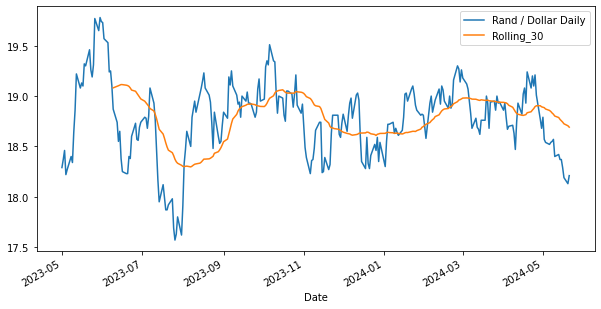

In [20]:
df['Rolling_30'] = df['Rand / Dollar Daily'].rolling(30).mean()
df.set_index('Date')[['Rand / Dollar Daily', 'Rolling_30']].plot(figsize=(10,5))
plt.show()

since our data has no sense of seasonality and we have seen our data has a constant mean we will do a hypothesis test to check if indeed this is true.we will use Augmented Dickey Fuller

h0=our data has a stable mean and variance hence being stationary
h1=our data has no stable mean and variance hence not being stationary

if we investigate and find our pvalue(threshold)<0.05 then we approve the hypothesis otherwise we reject the hypothesis


In [21]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['Rand / Dollar Daily'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -4.463402413055547
p-value: 0.00022885133539618467


conclusion:
data is stationary meaning stable mean stable variance no strong trend soo we will now feature engineer to check what is causing volatility if there is auto correlation

In [22]:
for lag in range(1, 8):  # creates lag 1 to lag 7
    df['Rand / Dollar Daily{lag}'] = df['Rand / Dollar Daily'].shift(lag)

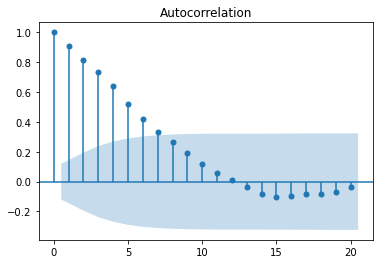

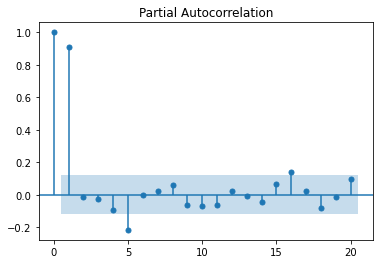

In [23]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(df['Rand / Dollar Daily{lag}'].dropna(), lags=20)
plot_pacf(df['Rand / Dollar Daily{lag}'].dropna(), lags=20)
plt.show()

Visual interpretation:
    for auto correlation it shows the direct and indirect correlations with the column we are checking and based on what we can see lag one is outside the confidence interval hence making it statistically significant
    For partial we can see what is directly correlating with today's exchange rate and 1 and 2 indeed shows the correlation and so we will use the two to investigate volatility and feature engineering

In [24]:
# Creating lag features then we drop the first 2 rows missing values and check results
df['lag_1'] = df['Rand / Dollar Daily'].shift(1)  # yesterday
df['lag_2'] = df['Rand / Dollar Daily'].shift(2)  # 2 days ago

df = df.dropna().reset_index(drop=True)

print(df[['Date','Rand / Dollar Daily','lag_1','lag_2','Rolling_30']].head())

        Date  Rand / Dollar Daily  lag_1  lag_2  Rolling_30
0 2023-06-09                18.87  19.10  19.25   19.081667
1 2023-06-12                18.74  18.87  19.10   19.096667
2 2023-06-13                18.55  18.74  18.87   19.102667
3 2023-06-14                18.65  18.55  18.74   19.109000
4 2023-06-15                18.38  18.65  18.55   19.114333


In [25]:
df.isna().sum().sum()

0

### MODELLING 
For our data we will use 4 models that is linear regression,ARIMA,random forest and XGboost we will compare the performance of the test set and see which one exactly generalizes

Linear Regression

In [26]:
# X = features, y = target
X = df[['lag_1', 'lag_2', 'Rolling_30']]
y = df['Rand / Dollar Daily']

In [27]:
X_train, X_test, y_train, y_test = train_test_split( X,y,train_size=0.8,shuffle=False)  

In [28]:
# Initialize model
lr = LinearRegression()
# Train model
lr.fit(X_train, y_train)

LinearRegression()

In [29]:
# Predict on test set
y_pred_lr = lr.predict(X_test)

In [30]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae = mean_absolute_error(y_test, y_pred_lr)

print("Linear Regression RMSE:", rmse)
print("Linear Regression MAE:", mae)

Linear Regression RMSE: 0.13370073143201797
Linear Regression MAE: 0.10573902301515815


In [31]:
y_train_pred = lr.predict(X_train)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
print("Train RMSE:", train_rmse)

Train RMSE: 0.15534849894564776


Random Forest

In [32]:
# Initialize model
rf = RandomForestRegressor(
    n_estimators=100,    # number of trees
    max_depth=5,         # limit depth to reduce overfitting
    random_state=42
)

In [33]:
# Train
rf.fit(X_train, y_train)

# Predict
y_pred_rf = rf.predict(X_test)

In [34]:
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print("Random Forest RMSE:", rmse_rf)
print("Random Forest MAE:", mae_rf)

Random Forest RMSE: 0.1520948214752604
Random Forest MAE: 0.11616182957178253


In [35]:
# Predict on train set
y_train_pred = rf.predict(X_train)

# Calculate RMSE
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_rmse

0.11055209496453446

HYPERTUNE THE PARAMETERS

In [36]:
# Parameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

In [37]:
rf = RandomForestRegressor(random_state=42)

grid_search_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,               
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

grid_search_rf.fit(X_train, y_train)
print("Best RF parameters:", grid_search_rf.best_params_)

# Best model
best_rf = grid_search_rf.best_estimator_

Best RF parameters: {'max_depth': 7, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}


In [39]:
# Predict on training set
train_pred_rf = best_rf.predict(X_train)

# Now calculate Train RMSE
rmse_rf_train = np.sqrt(mean_squared_error(y_train, train_pred_rf))

print("Tuned RF Train RMSE:", rmse_rf_train)

Tuned RF Train RMSE: 0.08726129090809549


In [40]:
# Evaluate
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

rmse_rf_test = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf_test = mean_absolute_error(y_test, y_pred_rf)
rmse_rf_train = np.sqrt(mean_squared_error(y_train, train_pred_rf))

print("Tuned RF Train RMSE:", rmse_rf_train)
print("Tuned RF Test RMSE:", rmse_rf_test)
print("Tuned RF Test MAE:", mae_rf_test)

Tuned RF Train RMSE: 0.08726129090809549
Tuned RF Test RMSE: 0.1520948214752604
Tuned RF Test MAE: 0.11616182957178253


### XGBOOST

In [42]:
xgb = XGBRegressor(objective='reg:squarederror', random_state=42)

param_grid_xgb = {
    'n_estimators': [50, 100, 200],
    'max_depth': [2, 3, 4],          # shallow trees
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.9, 1.0]
}

In [43]:
grid_search_xgb = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid_xgb,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

In [44]:
grid_search_xgb.fit(X_train, y_train)
best_xgb = grid_search_xgb.best_estimator_

print("Best XGBoost parameters:", grid_search_xgb.best_params_)

Best XGBoost parameters: {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 100, 'subsample': 0.9}


In [46]:
# Predict
y_pred_xgb = best_xgb.predict(X_test)
y_train_pred_xgb = best_xgb.predict(X_train)

In [47]:
# Metrics
rmse_xgb_train = np.sqrt(mean_squared_error(y_train, y_train_pred_xgb))
rmse_xgb_test = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae_xgb_test = mean_absolute_error(y_test, y_pred_xgb)

print("Tuned XGBoost Train RMSE:", rmse_xgb_train)
print("Tuned XGBoost Test RMSE:", rmse_xgb_test)
print("Tuned XGBoost Test MAE:", mae_xgb_test)

Tuned XGBoost Train RMSE: 0.11714740542244119
Tuned XGBoost Test RMSE: 0.15589014942420368
Tuned XGBoost Test MAE: 0.12097996520996077
